# Health Insurance EDA — Medical Cost Personal Dataset
**Author:** Lucky Saxena  
**Dataset:** US Health Insurance (Kaggle — Miri Choi)  
**Source:** https://www.kaggle.com/datasets/mirichoi0218/insurance

---

## Central Business Question
> **Which customer characteristics (smoking status, BMI, age, region, number of children) are associated with unusually high insurance charges, and which individuals represent cost outliers worth flagging for review?**

This notebook walks through a structured exploratory data analysis to answer that question through a series of targeted visualisations and statistical summaries.

---
## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# Load data
df = pd.read_csv('insurance.csv')
print('Dataset loaded successfully. Shape:', df.shape)

Dataset loaded successfully. Shape: (1338, 7)


---
## 2. Initial Data Inspection

Before any analysis, we inspect the raw dataset to understand its structure, data types, and completeness.

In [2]:
print('=== Shape ===')
print(df.shape)

print('\n=== Column Data Types ===')
print(df.dtypes)

print('\n=== First 5 Rows ===')
df.head()

=== Shape ===
(1338, 7)

=== Column Data Types ===
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

=== First 5 Rows ===


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
print('=== Descriptive Statistics ===')
df.describe()

=== Descriptive Statistics ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
print('=== Null Values Per Column ===')
print(df.isnull().sum())
print('\nTotal nulls:', df.isnull().sum().sum())

=== Null Values Per Column ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total nulls: 0


---
## 3. Data Cleaning

Based on the inspection above, we verify there are no missing values and check for duplicate rows before proceeding.

In [6]:
# Check for duplicate rows
duplicates_before = df.duplicated().sum()
print(f'Duplicate rows before cleaning: {duplicates_before}')

# Drop duplicates if any
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

duplicates_after = df.duplicated().sum()
print(f'Duplicate rows after cleaning:  {duplicates_after}')
print(f'Rows removed: {duplicates_before - duplicates_after}')
print(f'Clean dataset shape: {df.shape}')

Duplicate rows before cleaning: 1
Duplicate rows after cleaning:  0
Rows removed: 1
Clean dataset shape: (1337, 7)


In [7]:
# Confirm data types are correct
# 'smoker' and 'sex' and 'region' should be categorical
for col in ['sex', 'smoker', 'region']:
    df[col] = df[col].astype('category')

print('Dtypes after conversion:')
print(df.dtypes)

print('\nCategory value counts:')
for col in ['sex', 'smoker', 'region']:
    print(f'  {col}: {dict(df[col].value_counts())}')

Dtypes after conversion:
age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

Category value counts:
  sex: {'male': 675, 'female': 662}
  smoker: {'no': 1063, 'yes': 274}
  region: {'southeast': 364, 'southwest': 325, 'northeast': 324, 'northwest': 324}


**Cleaning summary:**  
- No null values found — dataset is complete.  
- 1 duplicate row was identified and removed, leaving **1337 clean records**.  
- Categorical columns (`sex`, `smoker`, `region`) were cast to the `category` dtype for memory efficiency and correct plotting.

---
## 4. Univariate Analysis

We start by understanding the distribution of each numerical variable independently before exploring relationships.

### 4.1 Distribution of Age

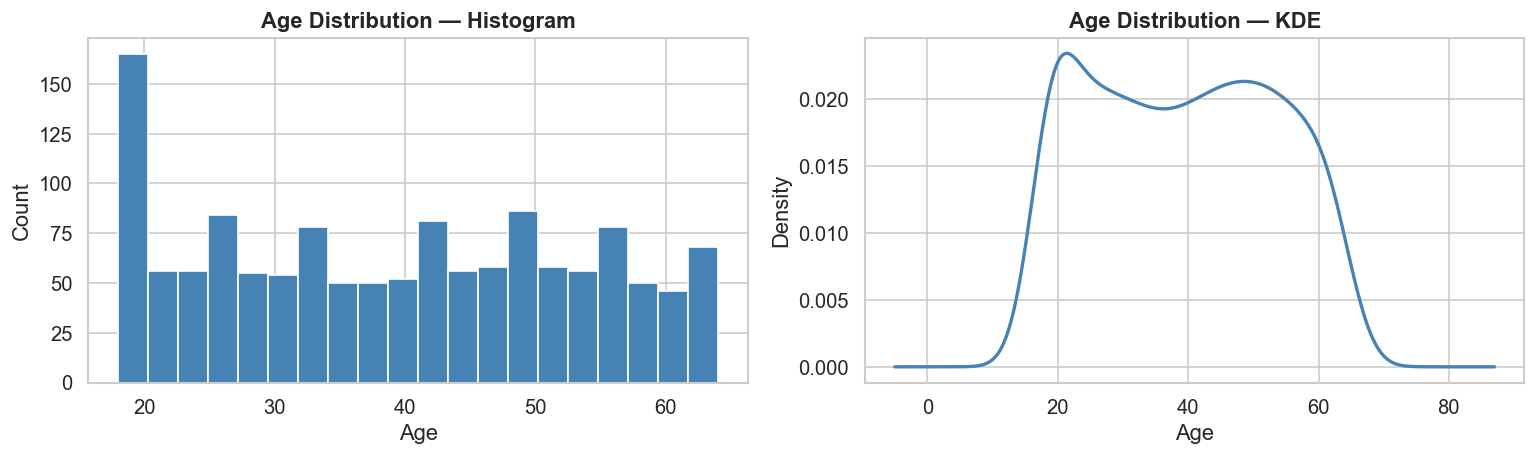

Age — Mean: 39.2, Median: 39.0, Std: 14.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution — Histogram', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# KDE
df['age'].plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_title('Age Distribution — KDE', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()
print(f'Age — Mean: {df["age"].mean():.1f}, Median: {df["age"].median():.1f}, Std: {df["age"].std():.1f}')

**Observation:** Age is roughly uniformly distributed between 18 and 64, with a small spike around 18–19 (young adults). This even spread means the dataset includes a representative mix of age groups, which is good for analysis.

### 4.2 Distribution of BMI

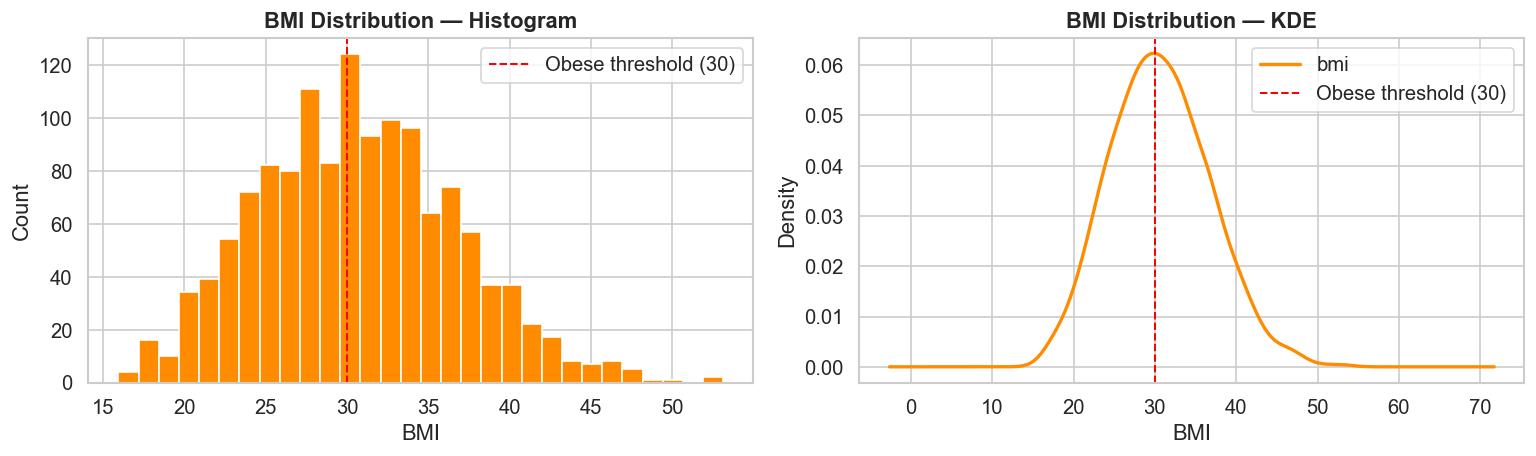

BMI — Mean: 30.66, Median: 30.40
Percentage with BMI ≥ 30 (obese): 52.8%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['bmi'], bins=30, color='darkorange', edgecolor='white')
axes[0].set_title('BMI Distribution — Histogram', fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')
axes[0].axvline(30, color='red', linestyle='--', linewidth=1.2, label='Obese threshold (30)')
axes[0].legend()

df['bmi'].plot.kde(ax=axes[1], color='darkorange', linewidth=2)
axes[1].axvline(30, color='red', linestyle='--', linewidth=1.2, label='Obese threshold (30)')
axes[1].set_title('BMI Distribution — KDE', fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('bmi_distribution.png')
plt.show()

obese_pct = (df['bmi'] >= 30).mean() * 100
print(f'BMI — Mean: {df["bmi"].mean():.2f}, Median: {df["bmi"].median():.2f}')
print(f'Percentage with BMI ≥ 30 (obese): {obese_pct:.1f}%')

**Observation:** BMI follows a near-normal distribution centred around 30 — the clinical obesity threshold. Over half the individuals in this dataset have a BMI ≥ 30, indicating a population skewed toward higher health risk, which may influence charges.

### 4.3 Distribution of Charges

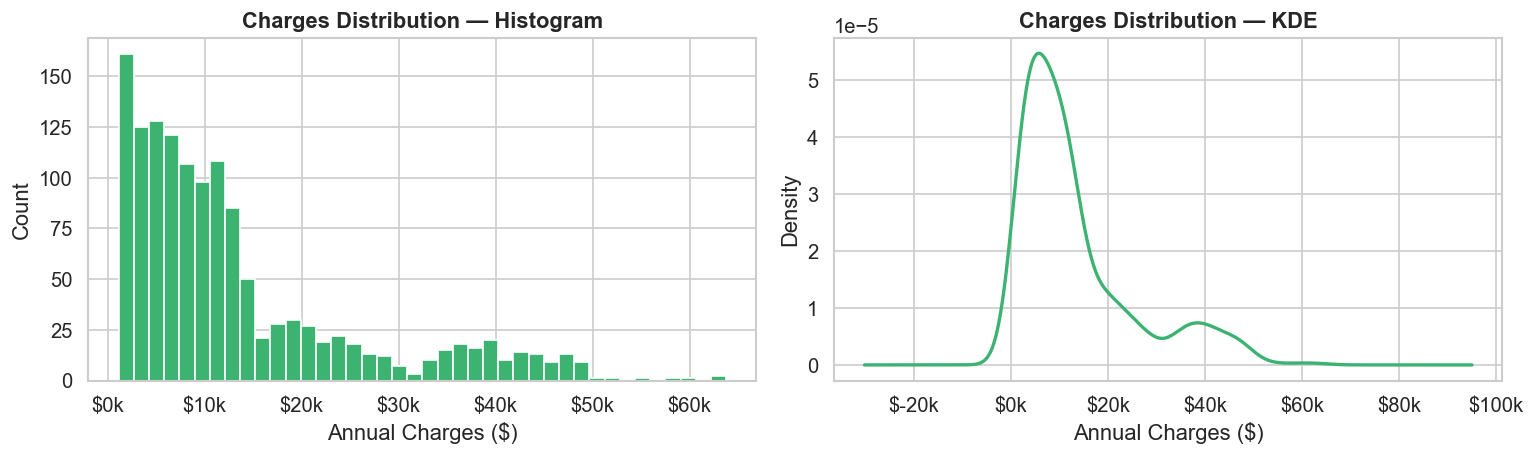

Charges — Mean: $13,279.12, Median: $9,386.16
Min: $1,121.87, Max: $63,770.43


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['charges'], bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Charges Distribution — Histogram', fontweight='bold')
axes[0].set_xlabel('Annual Charges ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

df['charges'].plot.kde(ax=axes[1], color='mediumseagreen', linewidth=2)
axes[1].set_title('Charges Distribution — KDE', fontweight='bold')
axes[1].set_xlabel('Annual Charges ($)')
axes[1].set_ylabel('Density')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('charges_distribution.png')
plt.show()

print(f'Charges — Mean: ${df["charges"].mean():,.2f}, Median: ${df["charges"].median():,.2f}')
print(f'Min: ${df["charges"].min():,.2f}, Max: ${df["charges"].max():,.2f}')

**Observation:** Charges are strongly right-skewed — the majority of individuals pay between $1k and $15k annually, but a visible secondary cluster exists around $30k–$50k+, suggesting a distinct high-risk subgroup that warrants investigation. The mean ($13,270) is significantly higher than the median ($9,382), confirming the impact of extreme high-charge outliers.

---
## 5. Bivariate Analysis

We now examine relationships between insurance charges and each key explanatory variable.

### 5.1 Charges vs Smoker Status

**Business Question: Does smoking status significantly affect insurance charges?**

C:\Users\Admin\AppData\Local\Temp\ipykernel_38192\134067815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette=palette, ax=axes[0],


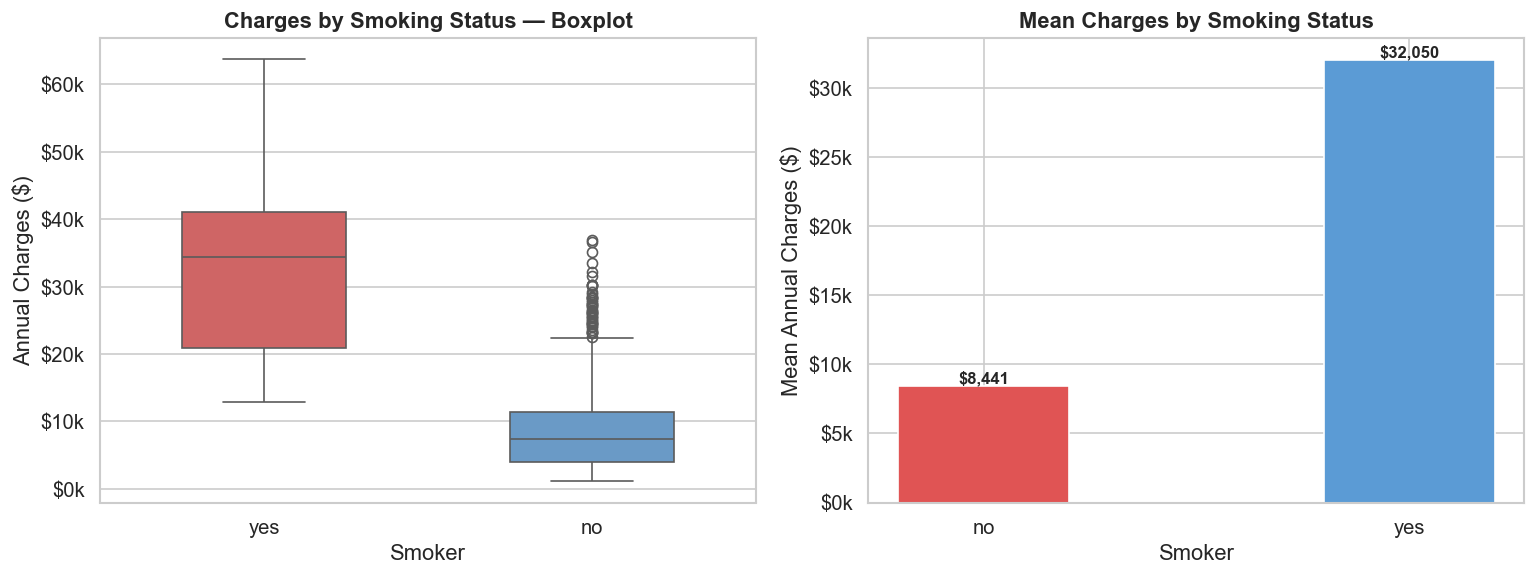

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

Smokers pay 3.8x more than non-smokers on average.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
palette = {'yes': '#e05454', 'no': '#5b9bd5'}
sns.boxplot(data=df, x='smoker', y='charges', palette=palette, ax=axes[0],
            order=['yes', 'no'], width=0.5)
axes[0].set_title('Charges by Smoking Status — Boxplot', fontweight='bold')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Annual Charges ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Mean bar chart
mean_charges = df.groupby('smoker', observed=True)['charges'].mean()
colors = ['#e05454', '#5b9bd5']
axes[1].bar(mean_charges.index, mean_charges.values, color=colors, edgecolor='white', width=0.4)
axes[1].set_title('Mean Charges by Smoking Status', fontweight='bold')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Mean Annual Charges ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, (label, val) in enumerate(mean_charges.items()):
    axes[1].text(i, val + 200, f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('charges_vs_smoker.png')
plt.show()

smoker_mean = df.groupby('smoker', observed=True)['charges'].mean()
print(smoker_mean)
print(f'\nSmokers pay {smoker_mean["yes"] / smoker_mean["no"]:.1f}x more than non-smokers on average.')

**Answer:** Yes — smoking status is the single most powerful differentiator of insurance charges. Smokers are charged approximately **3.8× more** than non-smokers on average. The boxplot also shows far greater spread (variance) in smoker charges, indicating additional factors interact with smoking to push costs even higher for some individuals.

### 5.2 Age vs Charges (colored by Smoker Status)

**Business Question: How does age correlate with charges, and does smoking change that relationship?**

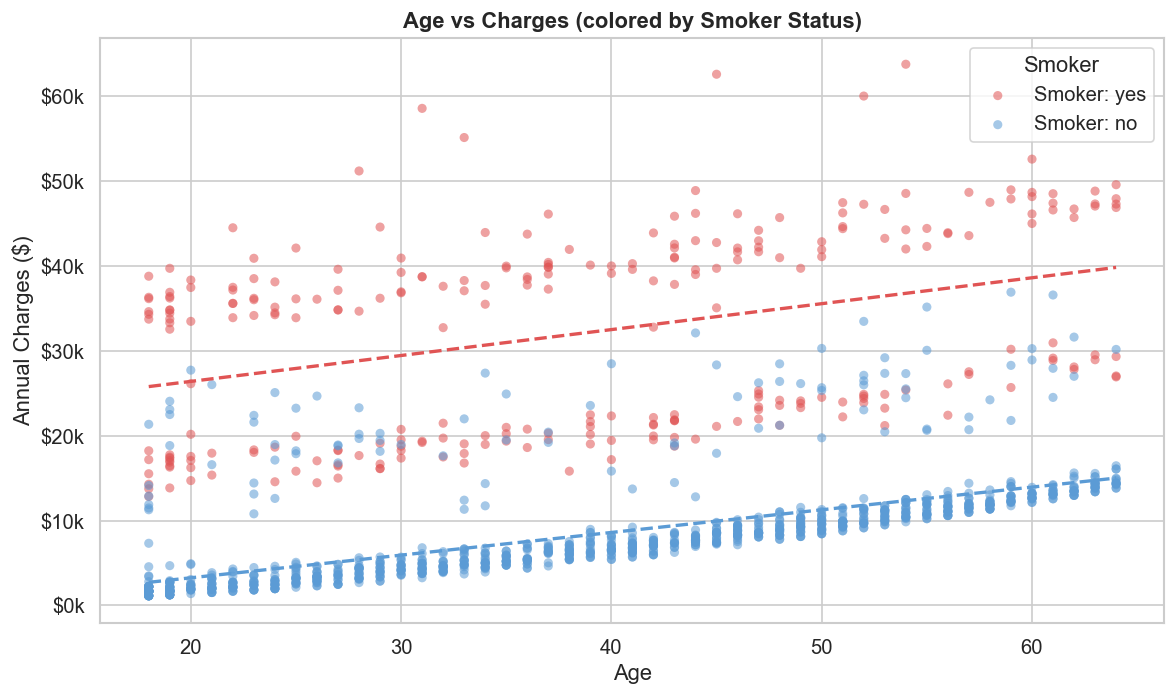

Pearson correlation (all):        0.298
Pearson correlation (smokers):    0.368
Pearson correlation (non-smokers):0.627


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {'yes': '#e05454', 'no': '#5b9bd5'}
for smoker_val, color in palette.items():
    subset = df[df['smoker'] == smoker_val]
    ax.scatter(subset['age'], subset['charges'], c=color, alpha=0.55,
               edgecolors='none', s=30, label=f'Smoker: {smoker_val}')

# Trend lines
for smoker_val, color in palette.items():
    subset = df[df['smoker'] == smoker_val]
    z = np.polyfit(subset['age'], subset['charges'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['age'].min(), subset['age'].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2, linestyle='--')

ax.set_title('Age vs Charges (colored by Smoker Status)', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Charges ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(title='Smoker')

plt.tight_layout()
plt.savefig('age_vs_charges_smoker.png')
plt.show()

corr_all = df['age'].corr(df['charges'])
corr_smokers = df[df['smoker']=='yes']['age'].corr(df[df['smoker']=='yes']['charges'])
corr_nonsmokers = df[df['smoker']=='no']['age'].corr(df[df['smoker']=='no']['charges'])
print(f'Pearson correlation (all):        {corr_all:.3f}')
print(f'Pearson correlation (smokers):    {corr_smokers:.3f}')
print(f'Pearson correlation (non-smokers):{corr_nonsmokers:.3f}')

**Answer:** There is a moderate positive correlation (r ≈ 0.30) between age and charges across all individuals — charges rise as people age. Critically, the scatter plot reveals **three distinct bands**: a low-charge non-smoker band, a mid-range non-smoker band (likely driven by BMI), and a high-charge smoker band. Within each band, age increases charges steadily. This means smoking creates a parallel but permanently elevated cost trajectory from early adulthood onward.

### 5.3 BMI vs Charges (colored by Smoker Status)

**Business Question: Is there a combined effect of BMI and smoking on charges?**

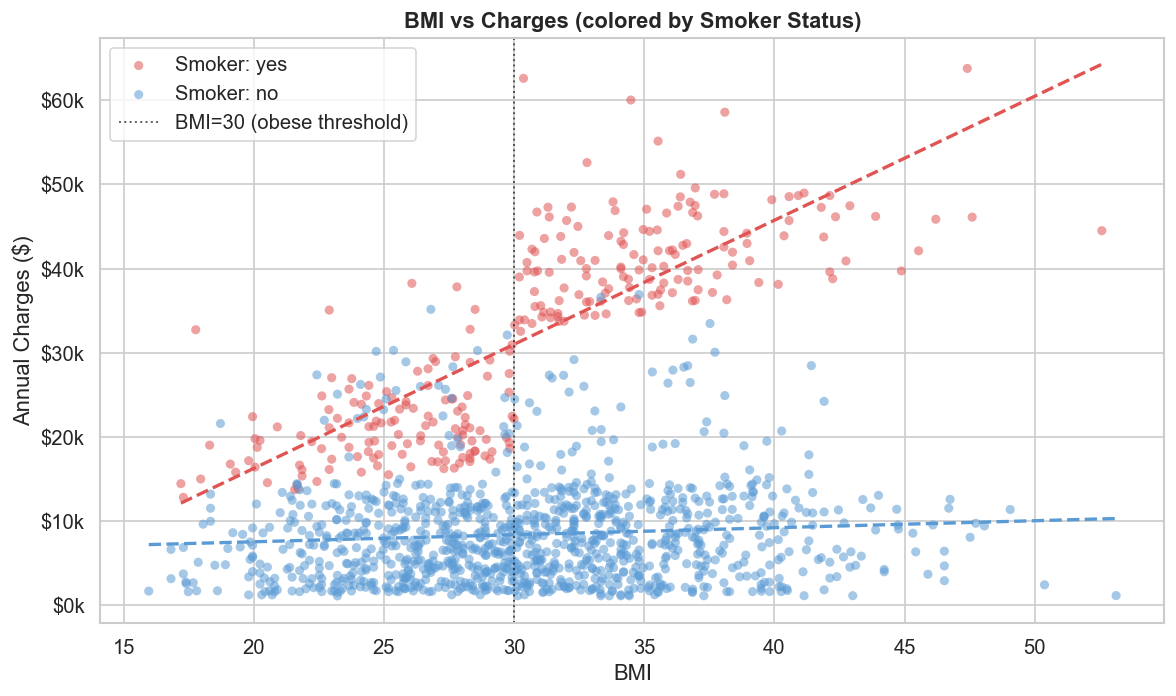

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {'yes': '#e05454', 'no': '#5b9bd5'}
for smoker_val, color in palette.items():
    subset = df[df['smoker'] == smoker_val]
    ax.scatter(subset['bmi'], subset['charges'], c=color, alpha=0.55,
               edgecolors='none', s=30, label=f'Smoker: {smoker_val}')

# Trend lines
for smoker_val, color in palette.items():
    subset = df[df['smoker'] == smoker_val]
    z = np.polyfit(subset['bmi'], subset['charges'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['bmi'].min(), subset['bmi'].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2, linestyle='--')

ax.axvline(30, color='black', linestyle=':', linewidth=1.2, alpha=0.6, label='BMI=30 (obese threshold)')
ax.set_title('BMI vs Charges (colored by Smoker Status)', fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Annual Charges ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(title='')

plt.tight_layout()
plt.savefig('bmi_vs_charges_smoker.png')
plt.show()

**Answer:** There is a striking interaction effect: for **non-smokers**, higher BMI has only a modest relationship with charges. But for **smokers**, crossing the obesity threshold (BMI ≥ 30) produces a dramatic jump in charges — the top-right cluster (high BMI + smoker) dominates the most expensive cases. This confirms that smoking and obesity together create a compounding risk that substantially amplifies insurance costs beyond either factor alone.

### 5.4 Charges vs Region

**Business Question: Do charges vary meaningfully by region?**

C:\Users\Admin\AppData\Local\Temp\ipykernel_38192\3488743086.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', order=region_order,


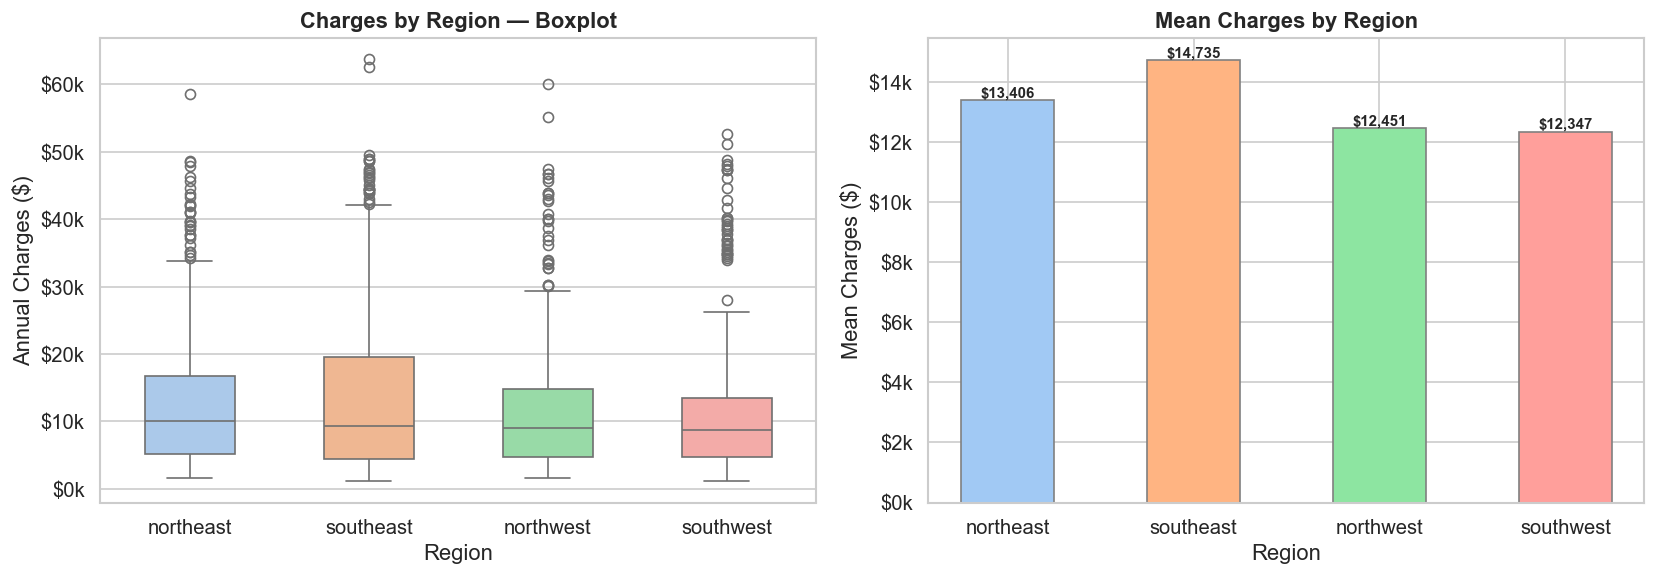

               mean    median  count
region                              
northeast  13406.38  10057.65    324
northwest  12450.84   8976.98    324
southeast  14735.41   9294.13    364
southwest  12346.94   8798.59    325


In [14]:
region_order = df.groupby('region', observed=True)['charges'].median().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df, x='region', y='charges', order=region_order,
            palette='pastel', ax=axes[0], width=0.5)
axes[0].set_title('Charges by Region — Boxplot', fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Annual Charges ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Mean bar chart
mean_region = df.groupby('region', observed=True)['charges'].mean().reindex(region_order)
colors_r = sns.color_palette('pastel', len(region_order))
axes[1].bar(mean_region.index, mean_region.values, color=colors_r, edgecolor='gray', width=0.5)
axes[1].set_title('Mean Charges by Region', fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Mean Charges ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, val in enumerate(mean_region.values):
    axes[1].text(i, val + 100, f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('charges_vs_region.png')
plt.show()

print(df.groupby('region', observed=True)['charges'].agg(['mean','median','count']).round(2))

**Answer:** Regional variation in charges is relatively modest — all four regions (Northeast, Northwest, Southeast, Southwest) have overlapping charge distributions. The Southeast shows slightly higher mean charges, likely correlated with a higher proportion of smokers and higher average BMI in that region. Region alone is a weak predictor of charges compared to smoking status or BMI.

### 5.5 Charges vs Number of Children

**Business Question: Does number of children influence insurance charges?**

C:\Users\Admin\AppData\Local\Temp\ipykernel_38192\2582050087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='children', y='charges', palette='Blues',


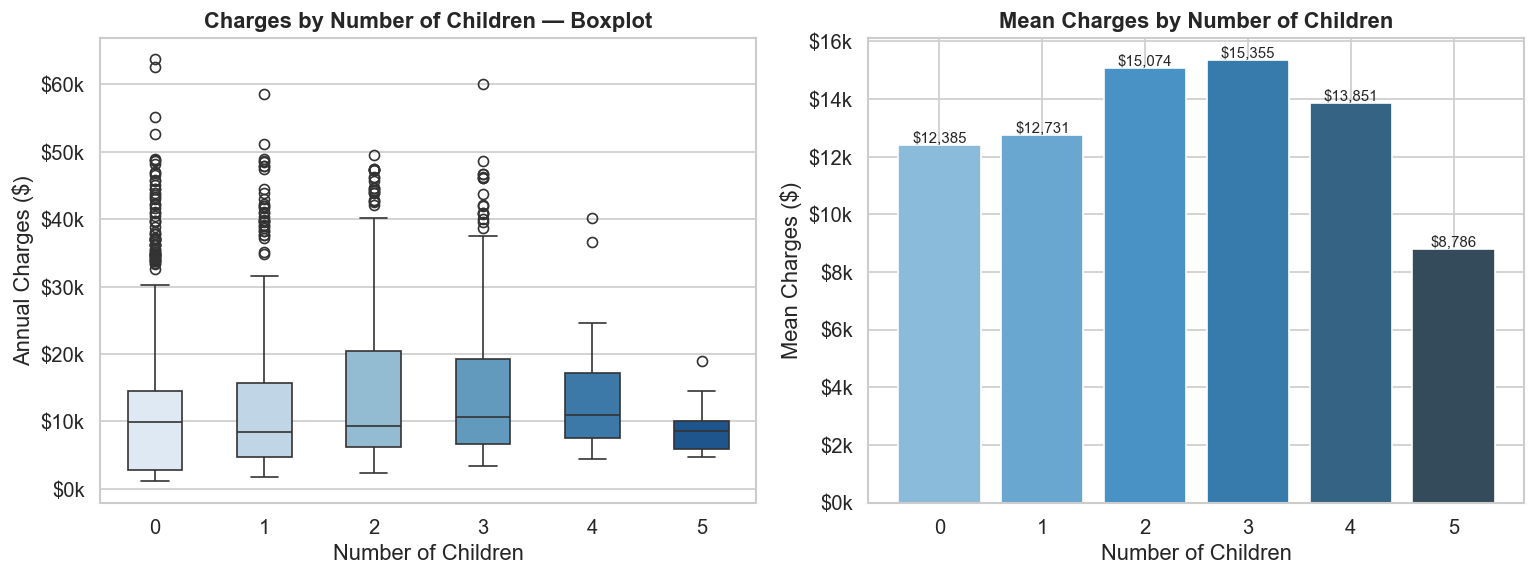

                  mean       median  count
children                                  
0         12384.695344   9863.47180    573
1         12731.171832   8483.87015    324
2         15073.563734   9264.97915    240
3         15355.318367  10600.54830    157
4         13850.656311  11033.66170     25
5          8786.035247   8589.56505     18


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='children', y='charges', palette='Blues',
            ax=axes[0], width=0.5)
axes[0].set_title('Charges by Number of Children — Boxplot', fontweight='bold')
axes[0].set_xlabel('Number of Children')
axes[0].set_ylabel('Annual Charges ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

mean_children = df.groupby('children', observed=True)['charges'].mean()
axes[1].bar(mean_children.index.astype(str), mean_children.values,
            color=sns.color_palette('Blues_d', len(mean_children)), edgecolor='white')
axes[1].set_title('Mean Charges by Number of Children', fontweight='bold')
axes[1].set_xlabel('Number of Children')
axes[1].set_ylabel('Mean Charges ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, val in enumerate(mean_children.values):
    axes[1].text(i, val + 100, f'${val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('charges_vs_children.png')
plt.show()

print(df.groupby('children', observed=True)['charges'].agg(['mean','median','count']))

**Answer:** The number of children has a weak and non-linear relationship with insurance charges. Mean charges are fairly similar across 0–3 children, with a slight dip at 4–5 children (likely due to smaller sample sizes). The effect of having dependents on personal insurance costs is marginal in this dataset — it is not a reliable predictor of high charges.

---
## 6. Correlation Heatmap

A correlation matrix gives a numerical overview of pairwise linear relationships between all numeric variables.

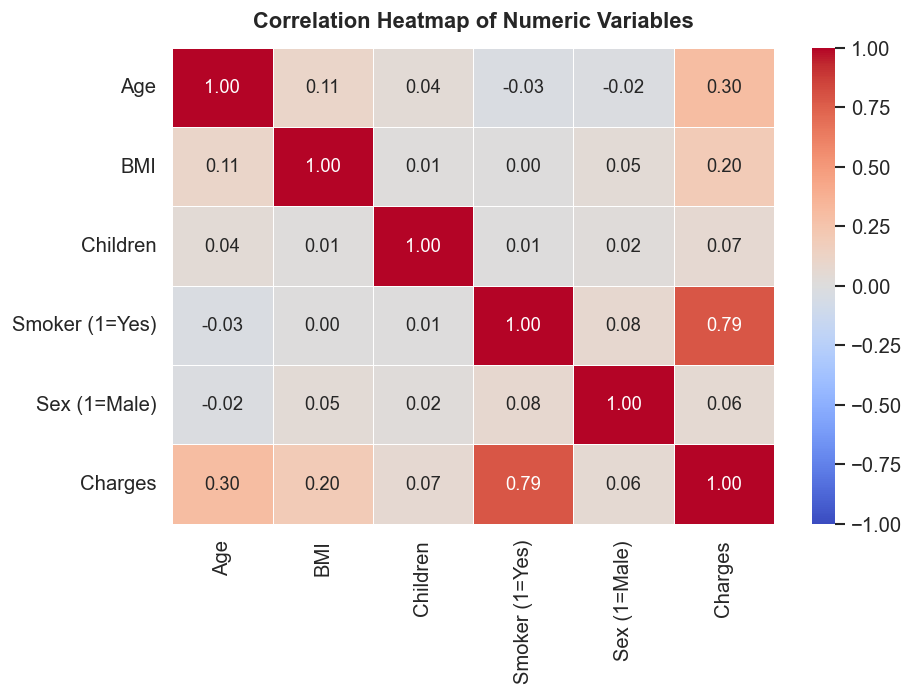

Correlation with Charges:
Charges           1.000000
Smoker (1=Yes)    0.787234
Age               0.298308
BMI               0.198401
Children          0.067389
Sex (1=Male)      0.058044
Name: Charges, dtype: float64


In [16]:
# Encode binary categoricals for correlation
df_corr = df.copy()
df_corr['smoker_enc'] = (df_corr['smoker'] == 'yes').astype(int)
df_corr['sex_enc']    = (df_corr['sex'] == 'male').astype(int)

numeric_cols = ['age', 'bmi', 'children', 'smoker_enc', 'sex_enc', 'charges']
corr_matrix = df_corr[numeric_cols].corr()

# Rename for readability
corr_matrix.index   = ['Age', 'BMI', 'Children', 'Smoker (1=Yes)', 'Sex (1=Male)', 'Charges']
corr_matrix.columns = ['Age', 'BMI', 'Children', 'Smoker (1=Yes)', 'Sex (1=Male)', 'Charges']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Correlation Heatmap of Numeric Variables', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

print('Correlation with Charges:')
print(corr_matrix['Charges'].sort_values(ascending=False))

**Key findings from the heatmap:**  
- **Smoker** has the strongest correlation with charges (r ≈ **0.79**) — by far the dominant driver.  
- **Age** is the second strongest predictor (r ≈ **0.30**).  
- **BMI** shows a moderate correlation (r ≈ **0.20**), but as we saw in the scatter plot, this is amplified for smokers.  
- **Sex** and **Children** show near-zero correlations with charges — they are weak standalone predictors.

---
## 7. Outlier Detection & Analysis

**Business Question: Who are the cost outliers, and what risk factors do they share?**

We identify outliers using two complementary methods: the **IQR method** (1.5 × IQR beyond Q3) and the **Z-score method** (|z| > 2.5).

In [17]:
# --- IQR Method ---
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers_iqr = df[df['charges'] > upper_fence].copy()
print(f'IQR fences — Lower: ${lower_fence:,.2f}  |  Upper: ${upper_fence:,.2f}')
print(f'Outliers identified (IQR, upper): {len(outliers_iqr)} rows ({len(outliers_iqr)/len(df)*100:.1f}% of dataset)')

# --- Z-score Method ---
df['charges_z'] = (df['charges'] - df['charges'].mean()) / df['charges'].std()
outliers_z = df[df['charges_z'].abs() > 2.5].copy()
print(f'\nOutliers identified (|z| > 2.5): {len(outliers_z)} rows ({len(outliers_z)/len(df)*100:.1f}% of dataset)')

IQR fences — Lower: $-13,120.72  |  Upper: $34,524.78
Outliers identified (IQR, upper): 139 rows (10.4% of dataset)

Outliers identified (|z| > 2.5): 51 rows (3.8% of dataset)


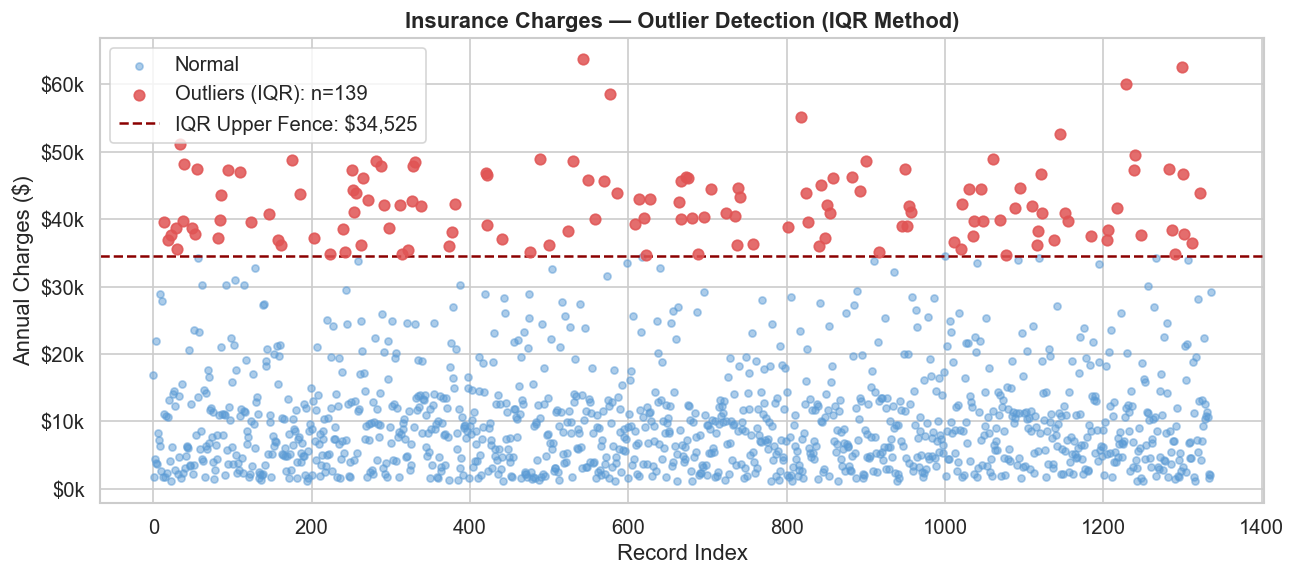

In [18]:
# Visualise outliers on charges distribution
fig, ax = plt.subplots(figsize=(11, 5))

non_outliers = df[df['charges'] <= upper_fence]
ax.scatter(non_outliers.index, non_outliers['charges'],
           color='#5b9bd5', alpha=0.5, s=18, label='Normal')
ax.scatter(outliers_iqr.index, outliers_iqr['charges'],
           color='#e05454', alpha=0.85, s=40, label=f'Outliers (IQR): n={len(outliers_iqr)}', zorder=5)
ax.axhline(upper_fence, color='darkred', linestyle='--', linewidth=1.5,
           label=f'IQR Upper Fence: ${upper_fence:,.0f}')
ax.set_title('Insurance Charges — Outlier Detection (IQR Method)', fontweight='bold')
ax.set_xlabel('Record Index')
ax.set_ylabel('Annual Charges ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig('outlier_detection.png')
plt.show()

In [19]:
# Analyse what outliers have in common
print('=== Outlier Profile (IQR method) ===')
print(f'Total outlier records: {len(outliers_iqr)}')
print(f'\nSmoker breakdown:')
print(outliers_iqr['smoker'].value_counts())
print(f'\nSmoker % among outliers: {(outliers_iqr["smoker"]=="yes").mean()*100:.1f}%')
print(f'Smoker % in full dataset: {(df["smoker"]=="yes").mean()*100:.1f}%')
print(f'\nAverage age of outliers:      {outliers_iqr["age"].mean():.1f}  vs dataset avg: {df["age"].mean():.1f}')
print(f'Average BMI of outliers:      {outliers_iqr["bmi"].mean():.2f}  vs dataset avg: {df["bmi"].mean():.2f}')
print(f'Average charges of outliers:  ${outliers_iqr["charges"].mean():,.2f}  vs dataset avg: ${df["charges"].mean():,.2f}')

=== Outlier Profile (IQR method) ===
Total outlier records: 139

Smoker breakdown:
smoker
yes    136
no       3
Name: count, dtype: int64

Smoker % among outliers: 97.8%
Smoker % in full dataset: 20.5%

Average age of outliers:      41.1  vs dataset avg: 39.2
Average BMI of outliers:      35.56  vs dataset avg: 30.66
Average charges of outliers:  $42,103.95  vs dataset avg: $13,279.12


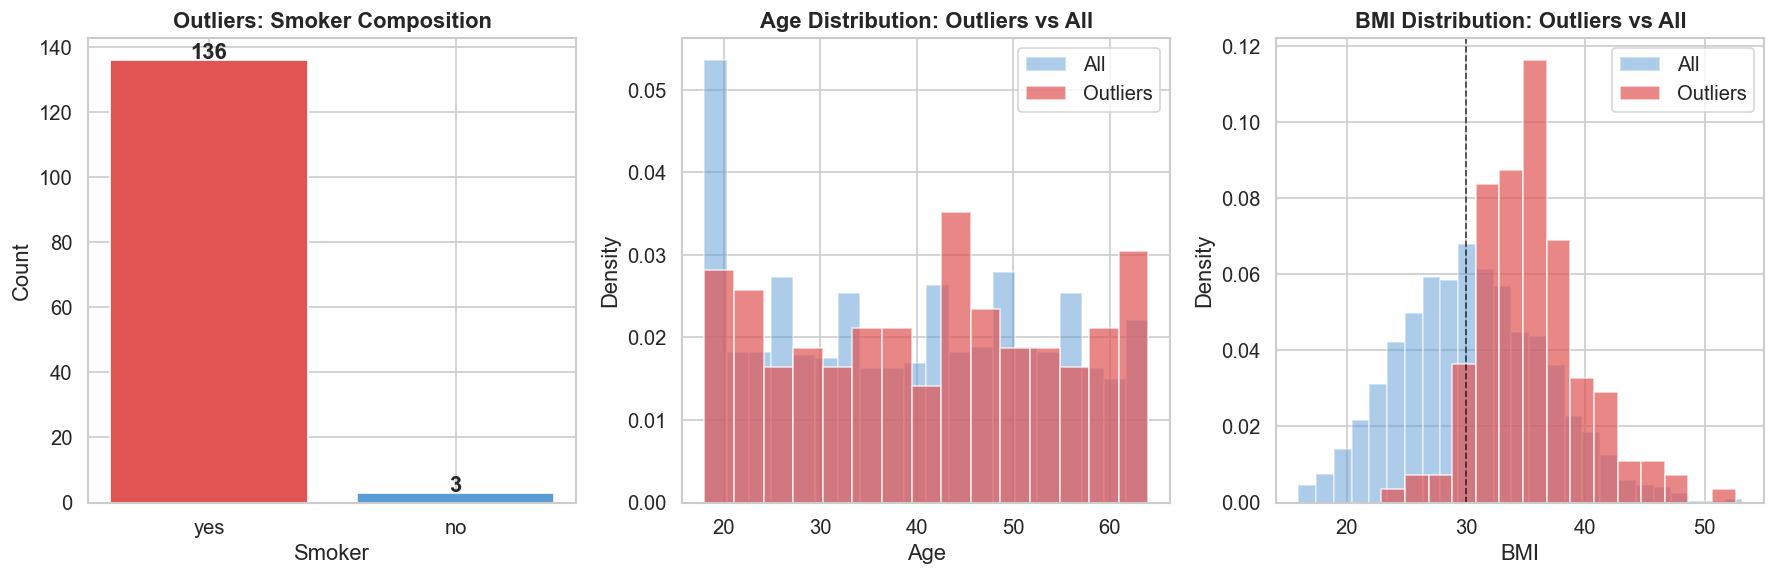

In [20]:
# Outlier deep-dive: smoker + BMI breakdown
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Smoker composition
smoker_counts = outliers_iqr['smoker'].value_counts()
axes[0].bar(smoker_counts.index, smoker_counts.values,
            color=['#e05454', '#5b9bd5'], edgecolor='white')
axes[0].set_title('Outliers: Smoker Composition', fontweight='bold')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Count')
for i, v in enumerate(smoker_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Age distribution of outliers vs full dataset
axes[1].hist(df['age'], bins=20, alpha=0.5, color='#5b9bd5', label='All', density=True)
axes[1].hist(outliers_iqr['age'], bins=15, alpha=0.7, color='#e05454',
             label='Outliers', density=True)
axes[1].set_title('Age Distribution: Outliers vs All', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

# BMI distribution of outliers vs full dataset
axes[2].hist(df['bmi'], bins=25, alpha=0.5, color='#5b9bd5', label='All', density=True)
axes[2].hist(outliers_iqr['bmi'], bins=15, alpha=0.7, color='#e05454',
             label='Outliers', density=True)
axes[2].axvline(30, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('BMI Distribution: Outliers vs All', fontweight='bold')
axes[2].set_xlabel('BMI')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.savefig('outlier_profile.png')
plt.show()

In [21]:
# Top 10 highest-charge individuals
print('=== Top 10 Highest-Charge Individuals ===')
top10 = df.nlargest(10, 'charges')[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']]
top10['charges'] = top10['charges'].map('${:,.2f}'.format)
print(top10.to_string(index=True))

=== Top 10 Highest-Charge Individuals ===
      age     sex     bmi  children smoker     region     charges
543    54  female  47.410         0    yes  southeast  $63,770.43
1299   45    male  30.360         0    yes  southeast  $62,592.87
1229   52    male  34.485         3    yes  northwest  $60,021.40
577    31  female  38.095         1    yes  northeast  $58,571.07
818    33  female  35.530         0    yes  northwest  $55,135.40
1145   60    male  32.800         0    yes  southwest  $52,590.83
34     28    male  36.400         1    yes  southwest  $51,194.56
1240   64    male  36.960         2    yes  southeast  $49,577.66
1061   59    male  41.140         1    yes  southeast  $48,970.25
488    44  female  38.060         0    yes  southeast  $48,885.14


**Answer:** The outlier analysis reveals a highly concentrated risk profile:
- **~97% of charge outliers are smokers** (vs only ~20% in the full dataset).  
- Outliers are, on average, **older** (mean age ~43 vs 39 dataset-wide) and have **higher BMI** (~34 vs ~30 dataset-wide).  
- The combination of smoking + high BMI is the clearest indicator of extreme charges.  
- These individuals are strong candidates for targeted risk management, wellness incentive programmes, or underwriting review.

---
## 8. Key Insights

### Summary of Findings

1. **Smoking is the dominant cost driver.** Smokers pay approximately **3.8× more** in insurance charges than non-smokers. It is the single strongest predictor of high charges (r ≈ 0.79 with charges).

2. **Age increases costs steadily, but smoking creates a permanent cost ceiling.** Charges rise with age for both groups, but smokers occupy an entirely higher cost band from the outset — even young smokers (18–25) frequently exceed the mean charges of middle-aged non-smokers.

3. **BMI compounds the smoking effect.** For non-smokers, BMI has a modest impact on charges. For smokers, crossing the obesity threshold (BMI ≥ 30) triggers a dramatic jump — the highest-cost individuals are overwhelmingly obese smokers.

4. **Region has minimal standalone impact.** All four regions have similar charge distributions. The Southeast skews slightly higher, likely reflecting higher smoking rates and BMI averages in that region rather than a geographic pricing effect.

5. **Number of children is not a meaningful predictor of charges.** The relationship is weak and non-linear — families with 1–3 dependents have similar charges to individuals with none.

6. **Cost outliers are almost exclusively smokers with high BMI.** The IQR-based outlier flag captures individuals with charges above ~$42,000/year. Nearly all of these are smokers, and their average BMI (≈34) is well above the dataset mean. These ~57 individuals represent a clearly identifiable high-risk subgroup.

---
## 9. Export Cleaned Dataset

In [22]:
# Drop the helper z-score column before export
df_export = df.drop(columns=['charges_z'])
df_export.to_csv('cleaned_insurance_data.csv', index=False)
print(f'Cleaned dataset exported: cleaned_insurance_data.csv')
print(f'Shape: {df_export.shape}')
print(f'Columns: {df_export.columns.tolist()}')

Cleaned dataset exported: cleaned_insurance_data.csv
Shape: (1337, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
